# AROME Daily Fetch — France Metropolitan Grid

Self-healing archive: queries the API for all available coverages,
compares against the local cache, downloads only what's missing.

Two modes:
- **Static** (daily cron): 00Z run, first 24h → analysis-quality daily archive
- **Dynamic** (every 3h): latest window → rolling near-real-time

Run this notebook (or the `sync()` function) any time — it catches up
automatically. If you missed 3 days, next run fetches all 3.

```
data/arome_daily/
  static/arome_daily_2026-07-15.nc    ← full 24h, analysis quality
  dynamic/arome_daily_2026-07-15.nc   ← assembled from 3h windows
```

In [1]:
from irrigator.forecasts.arome_processing import (
    sync_static,
    sync_forecast,
    sync_dynamic,
    get_available_coverages,
    parse_coverage_id,
    find_available_run_dates,
    load_arome_daily_cache,
    ensure_dirs,
    DAILY_DIR,
    RAW_DIR,
)
from collections import defaultdict
import os

REPO_ROOT = os.path.dirname(os.getcwd())
os.chdir(REPO_ROOT)

## Discover what's available

In [2]:


# Fetch and parse
raw_coverages = get_available_coverages()
parsed = [parse_coverage_id(c) for c in raw_coverages]
parsed = [p for p in parsed if p is not None]

# Index by variable
by_variable = defaultdict(list)
for p in parsed:
    by_variable[p["variable"]].append(p)

print(f"Total coverages: {len(parsed)}")
print(f"Unique variables: {len(by_variable)}")
print()
for var, items in sorted(by_variable.items()):
    dates = sorted(set(p["run_date"] for p in items))
    accums = sorted(set(p["accumulation"] or "instant" for p in items))
    print(f"  {var[:60]:60s} dates={dates[0]}→{dates[-1]}  accum={accums}")

Total coverages: 5750
Unique variables: 46

  AVERAGE_LIGHTNING_STRIKE_DENSITY_OVER_3HOURS__GROUND_OR_WATE dates=2026-06-13→2026-06-17  accum=['instant']
  BRIGHTNESS_TEMPERATURE__GROUND_OR_WATER_SURFACE              dates=2026-06-13→2026-06-17  accum=['instant']
  CONVECTIVE_AVAILABLE_POTENTIAL_ENERGY__GROUND_OR_WATER_SURFA dates=2026-06-13→2026-06-17  accum=['instant']
  CONVECTIVE_INHIBITION__GROUND_OR_WATER_SURFACE               dates=2026-06-13→2026-06-17  accum=['instant']
  DEW_POINT_TEMPERATURE__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND    dates=2026-06-13→2026-06-17  accum=['instant']
  DOWNWARD_DIRECT_SHORT_WAVE_RADIATION_FLUX__GROUND_OR_WATER_S dates=2026-06-13→2026-06-17  accum=['P1D', 'P2D', 'PT12H', 'PT18H', 'PT1H', 'PT3H', 'PT6H', 'PT9H']
  DOWNWARD_LONG_WAVE_RADIATION_FLUX__GROUND_OR_WATER_SURFACE   dates=2026-06-13→2026-06-17  accum=['P1D', 'P2D', 'PT12H', 'PT18H', 'PT1H', 'PT3H', 'PT6H', 'PT9H']
  DOWNWARD_SHORT_WAVE_RADIATION_FLUX__GROUND_OR_WATER_SURFACE  dates=2026-06-13→

---
## Variable mapping and fetch logic

In [ ]:
# Map our short names to API coverage base names
# VARS_INSTANTANEOUS = {
#     "temp_2m": {
#         "coverage": "TEMPERATURE__GROUND_OR_WATER_SURFACE",
#         "height": None,
#         "static_hours": list(range(0, 24)),   # all 24 for Tmin/Tmax
#         "dynamic_hours": [0, 1, 2],                  # single snapshot per window
#     },
# }

# VARS_ACCUMULATED = {
#     "precip": {
#         "coverage": "TOTAL_PRECIPITATION__GROUND_OR_WATER_SURFACE",
#         "static_accum": "P1D",     # 1 call, full day total
#         "dynamic_accum": "PT3H",   # 1 call per 3h window
#     },
# }


available_00z_dates = find_available_run_dates(parsed, run_hour=0)
print(f"Available 00Z dates: {available_00z_dates[0]} → {available_00z_dates[-1]} ({len(available_00z_dates)} days)")

Available 00Z dates: 2026-06-11 → 2026-06-15 (5 days)


## Run static archive

In [2]:

# === RUN STATIC SYNC ===
# Discovers all available 00Z dates, downloads missing ones, builds daily archives.

results = sync_static(overwrite=False)

for d, status in sorted(results.items()):
    marker = "✓" if status == "cached" else ("↓" if status == "fetched" else "✗")
    print(f"  {marker} {d}: {status}")

2026-06-18 09:41:27,850 Syncing static archive...
2026-06-18 09:43:51,588 [static] 2026-06-18: 74 calls
2026-06-18 09:44:02,555 [static] arome_daily_2026-06-18.nc → 20.8 MB
2026-06-18 09:44:02,557 Sync complete: 5 available, 4 cached, 1 fetched, 0 errors


  ✓ 2026-06-14: cached
  ✓ 2026-06-15: cached
  ✓ 2026-06-16: cached
  ✓ 2026-06-17: cached
  ↓ 2026-06-18: fetched


## Run dynamic archive

In [3]:
# === RUN DYNAMIC SYNC (optional, for near-real-time) ===
results_dyn = sync_dynamic(overwrite=False)

# ISSUE WITH THE FH BEING 0,3,6 : I THINK IT'S GOOD WHEN NO NEW IS AVAILABLE, BUT THE ISSUE COMES BECAUSE ITS OVER CONSUMING API CALLS FOR OLDER DATA

2026-06-18 09:44:02,568 Syncing dynamic archive...
2026-06-18 09:44:24,037 [dynamic] 2026-06-17T15: done
2026-06-18 09:44:44,268 [dynamic] 2026-06-17T18: done
2026-06-18 09:44:59,301 [dynamic] 2026-06-17T21: done
2026-06-18 09:45:17,116 [dynamic] 2026-06-18T00: done
2026-06-18 09:45:32,391 [dynamic] 2026-06-18T03: done
2026-06-18 09:45:37,732 [dynamic] arome_daily_2026-06-14.nc → 8 windows, 19.6 MB
2026-06-18 09:45:44,322 [dynamic] arome_daily_2026-06-15.nc → 8 windows, 20.3 MB
2026-06-18 09:45:49,756 [dynamic] arome_daily_2026-06-16.nc → 8 windows, 20.4 MB
2026-06-18 09:45:55,078 [dynamic] arome_daily_2026-06-17.nc → 8 windows, 19.9 MB
2026-06-18 09:45:57,039 [dynamic] arome_daily_2026-06-18.nc → 2 windows, 18.7 MB


## Run forecast archive (0-48h)

In [4]:
# === RUN STATIC SYNC ===
# Discovers all available 00Z dates, downloads missing ones, builds daily archives.

results = sync_forecast(overwrite=False)

for d, status in sorted(results.items()):
    marker = "✓" if status == "cached" else ("↓" if status == "fetched" else "✗")
    print(f"  {marker} {d}: {status}")


2026-06-18 09:45:57,049 Syncing forecast archive...
2026-06-18 09:50:16,480 [forecast] 2026-06-18: 146 calls
2026-06-18 09:50:25,514 [forecast] arome_daily_2026-06-18.nc → 41.3 MB
2026-06-18 09:50:25,521 Sync complete: 5 available, 4 cached, 1 fetched, 0 errors


  ✓ 2026-06-14: cached
  ✓ 2026-06-15: cached
  ✓ 2026-06-16: cached
  ✓ 2026-06-17: cached
  ↓ 2026-06-18: fetched


---
## Cache loader for the pipeline

In [9]:
# Cache status

for mode in ["static", "dynamic","forecast"]:
    cached = sorted((DAILY_DIR / mode).glob("arome_daily_*.nc"))
    if mode == "static":
        cached_static = cached
    elif mode == "dynamic":
        cached_dyn = cached
    print(f"\n{mode.upper()}: {len(cached)} files")
    if cached:
        dates = [f.stem.replace('arome_daily_', '') for f in cached]
        total_mb = sum(f.stat().st_size for f in cached) / 1e6
        print(f"  {dates[0]} → {dates[-1]} ({total_mb:.0f} MB, {total_mb/max(len(cached),1):.1f} MB/day)")


STATIC: 5 files
  2026-06-11 → 2026-06-15 (100 MB, 20.0 MB/day)

DYNAMIC: 5 files
  2026-06-11 → 2026-06-15 (98 MB, 19.6 MB/day)

FORECAST: 5 files
  2026-06-11 → 2026-06-15 (200 MB, 40.0 MB/day)


In [10]:
cached

[PosixPath('data/processed/arome/forecast/arome_daily_2026-06-11.nc'),
 PosixPath('data/processed/arome/forecast/arome_daily_2026-06-12.nc'),
 PosixPath('data/processed/arome/forecast/arome_daily_2026-06-13.nc'),
 PosixPath('data/processed/arome/forecast/arome_daily_2026-06-14.nc'),
 PosixPath('data/processed/arome/forecast/arome_daily_2026-06-15.nc')]

In [11]:
cached_static

[PosixPath('data/processed/arome/static/arome_daily_2026-06-11.nc'),
 PosixPath('data/processed/arome/static/arome_daily_2026-06-12.nc'),
 PosixPath('data/processed/arome/static/arome_daily_2026-06-13.nc'),
 PosixPath('data/processed/arome/static/arome_daily_2026-06-14.nc'),
 PosixPath('data/processed/arome/static/arome_daily_2026-06-15.nc')]

In [ ]:
import xarray as xr


stat = xr.open_dataset(cached_static[3])
dyn = xr.open_dataset(cached_dyn[3])
forecast = xr.open_dataset(cached[2])

import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(17, 6))

stat.t_mean.plot(ax=ax[0])
dyn.t_mean.plot(ax=ax[1])
forecast.isel(valid_time=1).t_mean.plot(ax=ax[2])
(stat.isel(valid_time=0) - forecast.isel(valid_time=1)).t_mean.plot(ax=ax[3])

plt.show()

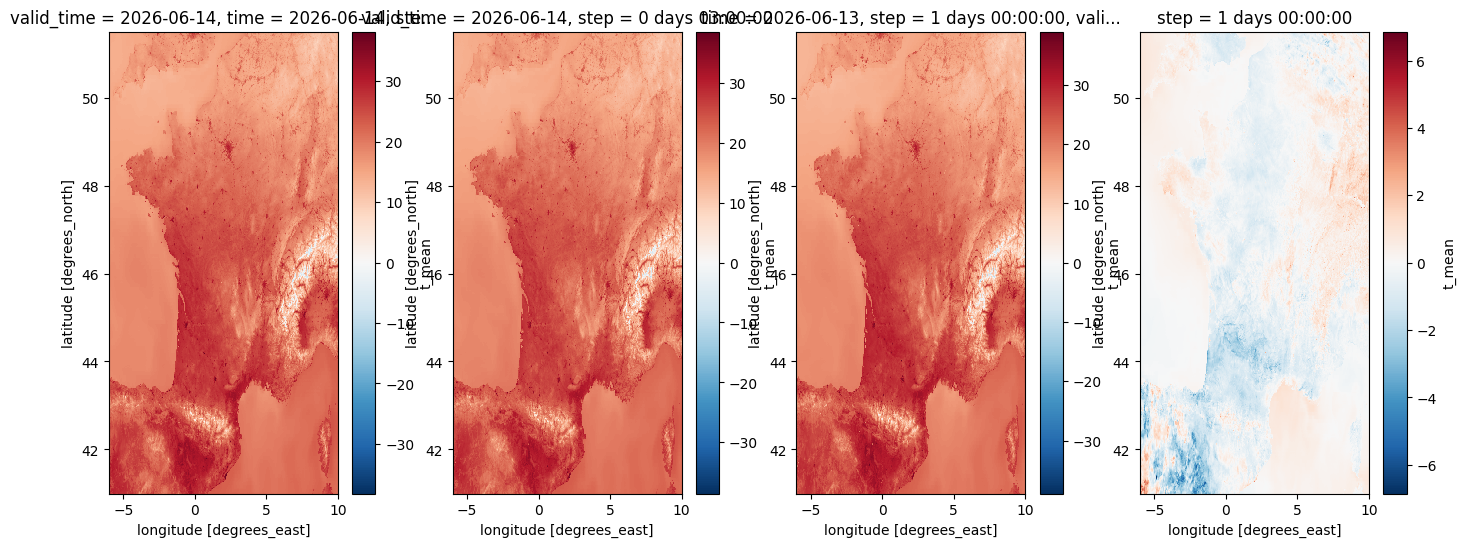